# Ten sensors provide the strongest warning signs of defective chips, giving engineers a focused place to investigate first

**Author:** Ilse Severance
**Course:** MSDS 696 -- Data Science Practicum II

**Research question:** Which of the 590 manufacturing process sensors most strongly distinguish failed chips from passed chips, and how should quality engineers prioritize investigating them to reduce defect rates?

**Context:** As a quality engineer, I want machine learning to do more than classify chips as pass/fail -- I want it to point to *which* process sensors are worth investigating first, so engineering time and cost go toward the leads most likely to reduce scrap, rework, and manufacturing cost. This notebook uses the SECOM dataset (590 anonymized sensor readings per chip, ~6.6% Fail rate) to build a defect-detection model, then uses that model's permutation importance -- cross-checked against an independent Mann-Whitney U test -- to produce a ranked, defensible shortlist of sensors for engineering follow-up.

**Notebook roadmap:** Research Problem (Fit / Provenance / Limits / Feasibility) -> Data Cleaning & Preprocessing -> EDA -> Feature Selection -> Model Comparison & Hyperparameter Tuning -> Threshold Selection -> Final Holdout Evaluation -> Feature Importance & Prioritization -> Conclusion.

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [222]:
src = r"C:\Users\nates\OneDrive\Desktop\MSDS\Data Practicum II"

X = pd.read_csv(f"{src}\\secom.data", sep=r"\s+", header=None)
X.columns = [f"feature_{i}" for i in range(X.shape[1])]

y = pd.read_csv(
    f"{src}\\secom_labels.data",
    sep=r"\s+",
    header=None,
    names=["label", "timestamp"],
)
y["timestamp"] = pd.to_datetime(y["timestamp"], dayfirst=True)

print(X.shape, y.shape)
X.head()

(1567, 590) (1567, 2)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_580,feature_581,feature_582,feature_583,feature_584,feature_585,feature_586,feature_587,feature_588,feature_589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [223]:
#Export the data to CSV files
# Combine features with label and timestamp
df = pd.concat([X, y], axis=1)

# Save to CSV
output_path = f"{src}\\secom_combined.csv"
df.to_csv(output_path, index=False)

print(f"Dataset saved to: {output_path}")
print(df.shape)
df.head()

Dataset saved to: C:\Users\nates\OneDrive\Desktop\MSDS\Data Practicum II\secom_combined.csv
(1567, 592)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_582,feature_583,feature_584,feature_585,feature_586,feature_587,feature_588,feature_589,label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,2008-07-19 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,2008-07-19 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,2008-07-19 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 15:22:00


## Research Problem: Fit, Provenance, Limits, Feasibility

In [224]:
#FIT: Does the dataset include sensor measurements and a pass/fail label per chip?
print("Sensor measurements:", X.shape[1], "columns (feature_0 ... feature_{})".format(X.shape[1] - 1))
print("Observations (chips):", X.shape[0])
print("Pass/fail label present:", "label" in y.columns)
print("Label values:", sorted(y["label"].unique()), "(-1 = Pass, 1 = Fail)")

Sensor measurements: 590 columns (feature_0 ... feature_589)
Observations (chips): 1567
Pass/fail label present: True
Label values: [-1, 1] (-1 = Pass, 1 = Fail)


In [225]:
#PROVENANCE: Where did this dataset come from?
with open(f"{src}\\secom.names", "r") as f:
    names_lines = f.read().splitlines()

for line in names_lines[:20]:
    print(line)

Title: SECOM Data Set

Abstract: Data from a semi-conductor manufacturing process
	

-----------------------------------------------------

Data Set Characteristics: Multivariate
Number of Instances: 1567
Area: Computer
Attribute Characteristics: Real
Number of Attributes: 591
Date Donated: 2008-11-19
Associated Tasks: Classification, Causal-Discovery
Missing Values? Yes

-----------------------------------------------------

Source:



In [226]:
#LIMITS: Imbalance, missing information (scrap/cost/variable names), dimensionality
fail_rate = (y["label"] == 1).mean() * 100
print(f"Class imbalance: {fail_rate:.1f}% of units are labeled Fail ({(y['label'] == 1).sum()} / {len(y)})")

cost_related_cols = [c for c in X.columns if any(k in c.lower() for k in ["cost", "scrap", "rework", "yield"])]
print(f"\nCost/scrap-related columns present: {len(cost_related_cols)}")
print("-> The dataset has no cost, scrap, or rework figures, only sensor readings and pass/fail")

print(f"\nFeature names are anonymized (no physical/process meaning): {list(X.columns[:5])} ...")

ratio = X.shape[0] / X.shape[1]
print(f"\nDimensionality: {X.shape[1]} features vs {X.shape[0]} observations "
      f"({ratio:.2f} rows per feature; only {(y['label'] == 1).sum()} Fail examples to learn from)")

Class imbalance: 6.6% of units are labeled Fail (104 / 1567)

Cost/scrap-related columns present: 0
-> The dataset has no cost, scrap, or rework figures, only sensor readings and pass/fail

Feature names are anonymized (no physical/process meaning): ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4'] ...

Dimensionality: 590 features vs 1567 observations (2.66 rows per feature; only 104 Fail examples to learn from)


In [227]:
#FEASIBILITY: Does the dataset contain what's needed to answer the research question?
has_sensor_data = X.shape[1] > 0
has_labels = "label" in y.columns
rows_aligned = len(X) == len(y)

print(f"Contains sensor measurements: {has_sensor_data} ({X.shape[1]} sensors)")
print(f"Contains defect (pass/fail) labels: {has_labels}")
print(f"Features and labels aligned (same row count): {rows_aligned} ({len(X)} == {len(y)})")

feasible = has_sensor_data and has_labels and rows_aligned
print(f"\n=> Feasible: {feasible} - the dataset contains the sensor measurements and defect labels "
      f"needed to model which process variables predict chip defects.")

Contains sensor measurements: True (590 sensors)
Contains defect (pass/fail) labels: True
Features and labels aligned (same row count): True (1567 == 1567)

=> Feasible: True - the dataset contains the sensor measurements and defect labels needed to model which process variables predict chip defects.


In [228]:
#Summary statistics, target distribution, missing values
#Dataset shape and column data types
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nColumn dtypes:")
print(X.dtypes.value_counts())

X shape: (1567, 590)
y shape: (1567, 2)

Column dtypes:
float64    590
Name: count, dtype: int64


label
Pass    1463
Fail     104
Name: count, dtype: int64
label
Pass    93.36
Fail     6.64
Name: proportion, dtype: float64


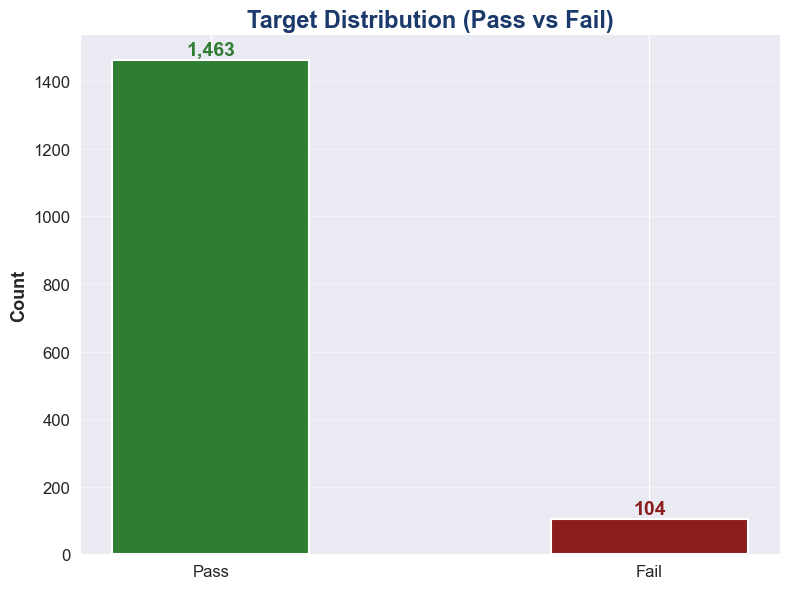

In [229]:
#Target variable distribution
target_counts = y["label"].value_counts().rename({-1: "Pass", 1: "Fail"})
target_pct = y["label"].value_counts(normalize=True).rename({-1: "Pass", 1: "Fail"}) * 100
outcome_colors = {"Pass": "#2E7D32", "Fail": "#8B1E1E"}  # matches Pass/Fail colors used elsewhere in the notebook

print(target_counts)
print(target_pct.round(2))

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = [outcome_colors[idx] for idx in target_counts.index]
bars = ax.bar(target_counts.index, target_counts.values, color=bar_colors, width=0.45,
               edgecolor="white", linewidth=1.5, zorder=3)

for bar, v in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 15, f"{v:,}",
            ha="center", fontsize=14, fontweight="bold", color=bar.get_facecolor())

ax.set_ylabel("Count", fontsize=13, fontweight="bold")
ax.tick_params(axis="both", labelsize=12)
ax.set_title("Target Distribution (Pass vs Fail)", fontsize=17, fontweight="bold", color="#1a3a6b")
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [230]:
#Numeric summary statistics
X.describe().T

,count,mean,std,min,25%,50%,75%,max
feature_0,1561.0,3014.452896,73.621787,2743.2400,2966.260000,3011.49000,3056.650000,3356.3500
feature_1,1560.0,2495.850231,80.407705,2158.7500,2452.247500,2499.40500,2538.822500,2846.4400
feature_2,1553.0,2200.547318,29.513152,2060.6600,2181.044400,2201.06670,2218.055500,2315.2667
feature_3,1553.0,1396.376627,441.691640,0.0000,1081.875800,1285.21440,1591.223500,3715.0417
feature_4,1553.0,4.197013,56.355540,0.6815,1.017700,1.31680,1.525700,1114.5366
...,...,...,...,...,...,...,...,...
feature_585,1566.0,3.067826,3.578033,1.1975,2.306500,2.75765,3.295175,99.3032
feature_586,1566.0,0.021458,0.012358,-0.0169,0.013425,0.02050,0.027600,0.1028
feature_587,1566.0,0.016475,0.008808,0.0032,0.010600,0.01480,0.020300,0.0799
feature_588,1566.0,0.005283,0.002867,0.0010,0.003300,0.00460,0.006400,0.0286


In [231]:
#Missing values analysis
missing_counts = X.isna().sum()
missing_pct = (missing_counts / len(X) * 100).round(2)

missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print(f"Columns with missing values: {len(missing_summary)} / {X.shape[1]}")
print(f"Total missing cells: {missing_counts.sum()} ({missing_counts.sum() / X.size * 100:.2f}% of all values)")
missing_summary.head(20)

Columns with missing values: 538 / 590
Total missing cells: 41951 (4.54% of all values)


,missing_count,missing_pct
feature_292,1429,91.19
feature_293,1429,91.19
feature_157,1429,91.19
feature_158,1429,91.19
feature_358,1341,85.58
feature_85,1341,85.58
feature_492,1341,85.58
feature_220,1341,85.58
feature_518,1018,64.96
feature_246,1018,64.96


In [232]:
#Percentage of missing values per observation (row)
missing_pct_row = (X.isna().sum(axis=1) / X.shape[1] * 100)

print("Percentage of missing values per observation:")
print(missing_pct_row.describe().round(2))

Percentage of missing values per observation:
count    1567.00
mean        4.54
std         2.27
min         0.68
25%         3.39
50%         4.07
75%         5.42
max        25.76
dtype: float64


        feature_count  pct_of_features  \
0%                 52              8.8   
1-20%             506             85.8   
20-50%              4              0.7   
50-80%             20              3.4   
>80%                8              1.4   

                                           recommendation  
0%           Keep as-is - complete data, no action needed  
1-20%   Impute (median/KNN) - low missingness, safe to...  
20-50%  Impute + add a missing-indicator flag - modera...  
50-80%  Use with caution - consider indicator-only, or...  
>80%                 Drop - too sparse to impute reliably  


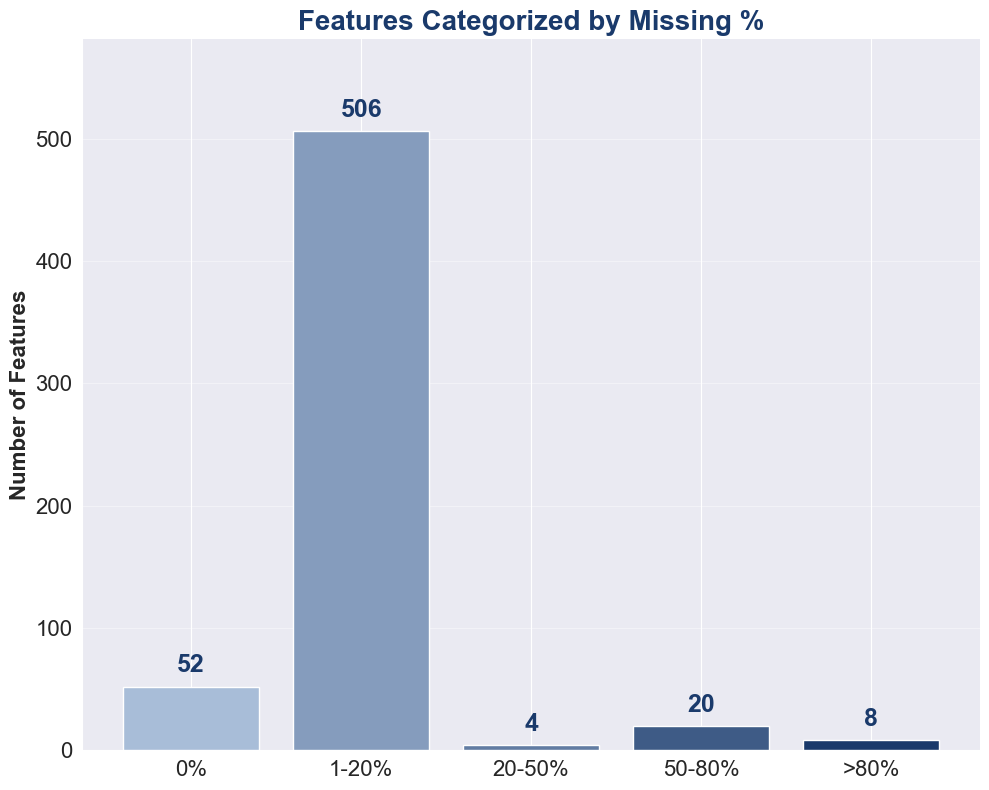

In [233]:
#Categorize features by missing percentage
missing_pct_all = (X.isna().sum() / len(X) * 100)

bins = [-0.001, 0, 20, 50, 80, 100]
labels = ["0%", "1-20%", "20-50%", "50-80%", ">80%"]
missing_category = pd.cut(missing_pct_all, bins=bins, labels=labels)

recommendation_map = {
    "0%": "Keep as-is - complete data, no action needed",
    "1-20%": "Impute (median/KNN) - low missingness, safe to fill",
    "20-50%": "Impute + add a missing-indicator flag - moderate missingness may itself be informative",
    "50-80%": "Use with caution - consider indicator-only, or drop unless known to be important",
    ">80%": "Drop - too sparse to impute reliably",
}

category_summary = missing_category.value_counts().reindex(labels).rename("feature_count").to_frame()
category_summary["pct_of_features"] = (category_summary["feature_count"] / X.shape[1] * 100).round(1)
category_summary["recommendation"] = category_summary.index.map(recommendation_map)

print(category_summary)

#Sequential navy ramp (light -> dark) since these bins are ordinal - darker means more missing
RAMP = ["#a8bdd8", "#859cbd", "#617ca2", "#3e5b86", "#1a3a6b"]

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 8))

counts = category_summary["feature_count"]
bars = ax.bar(counts.index, counts.values, color=RAMP, edgecolor="white", linewidth=1, zorder=3)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.015,
            f"{int(count)}", ha="center", va="bottom", fontsize=18, fontweight="bold", color="#1a3a6b")

ax.set_ylabel("Number of Features", fontsize=16, fontweight="bold")
ax.set_title("Features Categorized by Missing %", fontsize=20, fontweight="bold", color="#1a3a6b")
ax.set_ylim(0, counts.max() * 1.15)

ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

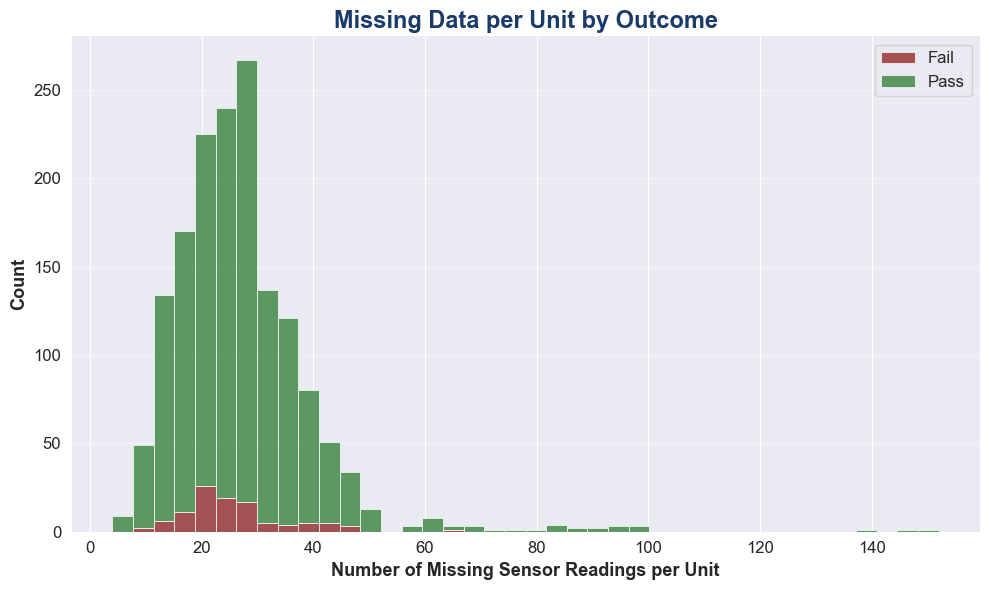

In [234]:
# Viz: Missing sensor readings per unit, split by Pass/Fail
y_readable = y["label"].map({-1: "Pass", 1: "Fail"})
missing_per_row = X.isna().sum(axis=1)
outcome_colors = {"Pass": "#2E7D32", "Fail": "#8B1E1E"}  # matches Pass/Fail colors used elsewhere in the notebook

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    x=missing_per_row, hue=y_readable, hue_order=["Pass", "Fail"],
    bins=40, multiple="stack", palette=outcome_colors,
    edgecolor="white", linewidth=0.5, ax=ax, zorder=3,
)

ax.set_xlabel("Number of Missing Sensor Readings per Unit", fontsize=13, fontweight="bold")
ax.set_ylabel("Count", fontsize=13, fontweight="bold")
ax.tick_params(axis="both", labelsize=12)
ax.set_title("Missing Data per Unit by Outcome", fontsize=17, fontweight="bold", color="#1a3a6b")
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="", labels=["Fail", "Pass"], fontsize=12, loc="upper right")

plt.tight_layout()
plt.show()

In [235]:
#Train/test split - stratified to preserve the Pass/Fail ratio in both sets (Fail is only ~6.6% of the data).
#Split BEFORE any cleaning step (dropping high-missing columns, imputation, near-zero-variance filtering)
#so every statistic used to clean the data is learned from X_train only - the test set stays completely
#untouched until final evaluation.
from sklearn.model_selection import train_test_split, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X, y["label"], test_size=0.2, random_state=42, stratify=y["label"]
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Stratified k-fold CV on the training set - used for model selection/tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    fold_fail_pct = (y_train.iloc[val_idx] == 1).mean() * 100
    print(f"Fold {fold+1}: val size={len(val_idx)}, Fail % in val={fold_fail_pct:.1f}")

Train shape: (1253, 590), Test shape: (314, 590)
Fold 1: val size=251, Fail % in val=6.8
Fold 2: val size=251, Fail % in val=6.8
Fold 3: val size=251, Fail % in val=6.8
Fold 4: val size=250, Fail % in val=6.4
Fold 5: val size=250, Fail % in val=6.4


In [236]:
#We will proceed to remove the features with more than 80% missing values.
#Computed on X_train only (not the full dataset) so the choice of which columns to drop
#doesn't leak any information from the held-out test set.
missing_pct_train = (X_train.isna().sum() / len(X_train) * 100)
high_missing_features = missing_pct_train[missing_pct_train > 80].index

X_train = X_train.drop(columns=high_missing_features)
X_test = X_test.drop(columns=high_missing_features)

print(f"Dropped {len(high_missing_features)} features with >80% missing values (threshold learned from X_train)")
print(f"Remaining shape - train: {X_train.shape}, test: {X_test.shape}")

Dropped 8 features with >80% missing values (threshold learned from X_train)
Remaining shape - train: (1253, 582), test: (314, 582)


Overall % of missing values by class (train set):
Fail    3.06
Pass    3.46
dtype: float64


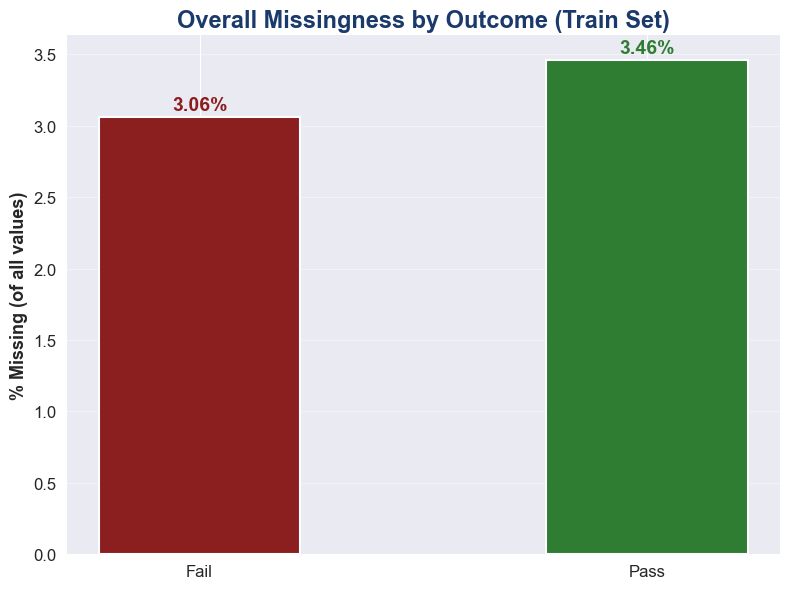


Per-row missing % summary by class (train set):
          count  mean   std   min   25%   50%   75%    max
outcome                                                   
Fail       83.0  3.06  1.48  0.69  2.06  2.75  3.44   6.87
Pass     1170.0  3.46  2.35  0.00  2.06  3.44  4.12  24.74


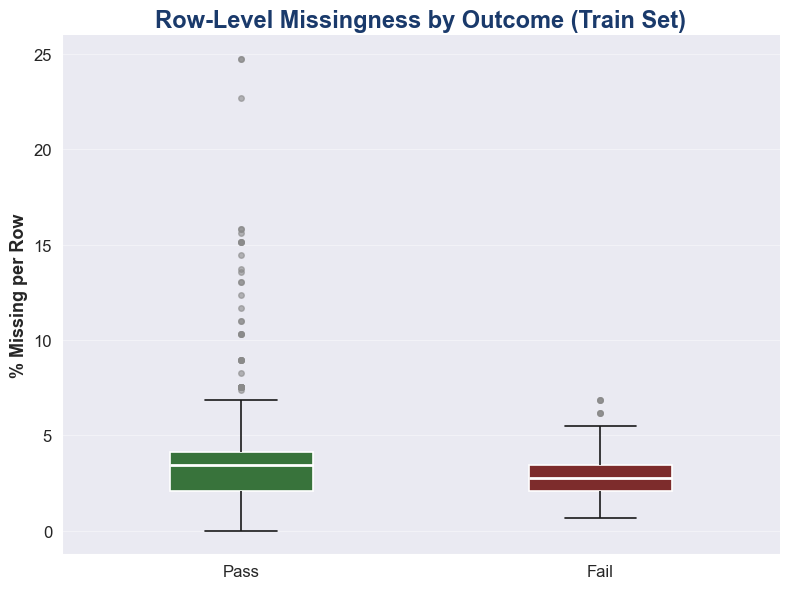

In [237]:
#Are missing values concentrated in defective (Fail) chips or good (Pass) chips?
#Explored on X_train/y_train only - this is pattern discovery to inform preprocessing decisions,
#kept out of the untouched test set.
outcome_train = y_train.map({-1: "Pass", 1: "Fail"})
outcome_colors = {"Pass": "#2E7D32", "Fail": "#8B1E1E"}  # matches Pass/Fail colors used elsewhere in the notebook

# Overall % of missing values within each class (missing cells / total cells for that class)
class_missing_pct = X_train.groupby(outcome_train.values).apply(lambda df: df.isna().sum().sum() / df.size * 100).round(2)
print("Overall % of missing values by class (train set):")
print(class_missing_pct)

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = [outcome_colors[idx] for idx in class_missing_pct.index]
bars = ax.bar(class_missing_pct.index, class_missing_pct.values, color=bar_colors, width=0.45,
               edgecolor="white", linewidth=1.5, zorder=3)

for bar, v in zip(bars, class_missing_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, f"{v:.2f}%",
            ha="center", fontsize=14, fontweight="bold", color=bar.get_facecolor())

ax.set_ylabel("% Missing (of all values)", fontsize=13, fontweight="bold")
ax.tick_params(axis="both", labelsize=12)
ax.set_title("Overall Missingness by Outcome (Train Set)", fontsize=17, fontweight="bold", color="#1a3a6b")
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Row-level view: distribution of per-row missing % within each class
missing_pct_row_train = (X_train.isna().sum(axis=1) / X_train.shape[1] * 100)
missing_by_outcome = pd.DataFrame({"missing_pct_row": missing_pct_row_train, "outcome": outcome_train})
print("\nPer-row missing % summary by class (train set):")
print(missing_by_outcome.groupby("outcome")["missing_pct_row"].describe().round(2))

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=missing_by_outcome, x="outcome", y="missing_pct_row", order=["Pass", "Fail"],
            palette=outcome_colors, width=0.4, ax=ax,
            boxprops=dict(edgecolor="white", linewidth=1.2),
            medianprops=dict(color="white", linewidth=2),
            whiskerprops=dict(color="#1a1a1a", linewidth=1.2),
            capprops=dict(color="#1a1a1a", linewidth=1.2),
            flierprops=dict(markerfacecolor="#8a8a8a", markeredgecolor="#8a8a8a", markersize=4, alpha=0.6))

ax.set_xlabel("")
ax.set_ylabel("% Missing per Row", fontsize=13, fontweight="bold")
ax.tick_params(axis="both", labelsize=12)
ax.set_title("Row-Level Missingness by Outcome (Train Set)", fontsize=17, fontweight="bold", color="#1a3a6b")
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

Rows missing more than 20% of sensors: 3 / 1253

Worst 10 rows by % missing:
1566    24.742268
1564    24.742268
1561    22.680412
511     15.807560
1152    15.807560
810     15.635739
95      15.120275
995     15.120275
93      15.120275
814     15.120275
dtype: float64


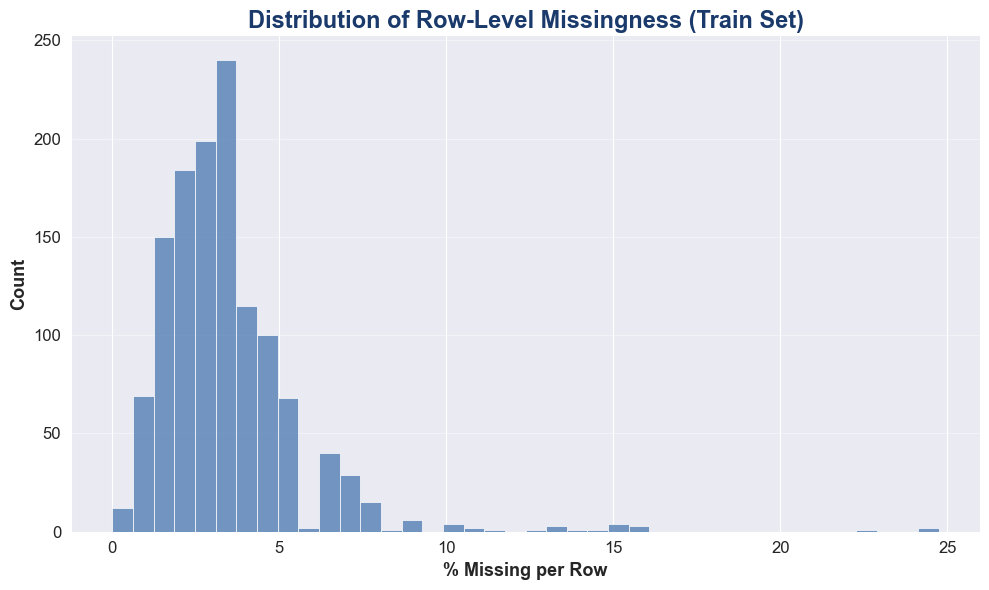

In [238]:
#Are some rows missing many sensors? (train set)
high_missing_rows = missing_pct_row_train[missing_pct_row_train > 20]
print(f"Rows missing more than 20% of sensors: {len(high_missing_rows)} / {len(missing_pct_row_train)}")
print("\nWorst 10 rows by % missing:")
print(missing_pct_row_train.sort_values(ascending=False).head(10))

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(missing_pct_row_train, bins=40, ax=ax, color="#4a78b0", edgecolor="white", linewidth=0.5, zorder=3)

ax.set_xlabel("% Missing per Row", fontsize=13, fontweight="bold")
ax.set_ylabel("Count", fontsize=13, fontweight="bold")
ax.tick_params(axis="both", labelsize=12)
ax.set_title("Distribution of Row-Level Missingness (Train Set)", fontsize=17, fontweight="bold", color="#1a3a6b")
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [239]:
#Impute remaining missing values - keep all observations (Fail class is scarce, can't afford to lose rows)
#
#We use median imputation as the primary method rather than KNN imputation. Median imputation is
#robust to outliers, computationally efficient, and well suited to high-dimensional manufacturing
#data. With 580+ remaining features and only ~1,250 training observations, plus many correlated
#manufacturing variables, distance calculations in KNN become less meaningful in such high dimensions
#and more computationally expensive. KNN imputation could be evaluated later as part of a sensitivity
#analysis, but is not used as the primary preprocessing method here.
#
#Both which columns get an indicator flag and the imputation medians themselves are learned from
#X_train only, then applied unchanged to X_test - this keeps test-set information out of preprocessing.
from sklearn.impute import SimpleImputer

missing_pct_train = (X_train.isna().sum() / len(X_train) * 100)

#Features with 20-80% missing may have informative missingness - add an indicator flag before imputing
indicator_features = missing_pct_train[(missing_pct_train >= 20) & (missing_pct_train <= 80)].index
for col in indicator_features:
    X_train[f"{col}_was_missing"] = X_train[col].isna().astype(int)
    X_test[f"{col}_was_missing"] = X_test[col].isna().astype(int)

print(f"Added missing-indicator flags for {len(indicator_features)} features (20-80% missing, learned from X_train)")

#Median-impute all original sensor columns - fit on X_train, apply the same medians to X_test
sensor_cols = [c for c in X_train.columns if not c.endswith("_was_missing")]
imputer = SimpleImputer(strategy="median")
X_train[sensor_cols] = imputer.fit_transform(X_train[sensor_cols])
X_test[sensor_cols] = imputer.transform(X_test[sensor_cols])

print(f"Remaining missing values - train: {X_train[sensor_cols].isna().sum().sum()}, test: {X_test[sensor_cols].isna().sum().sum()}")
print(f"Final shape - train: {X_train.shape}, test: {X_test.shape}")

Added missing-indicator flags for 24 features (20-80% missing, learned from X_train)
Remaining missing values - train: 0, test: 0
Final shape - train: (1253, 606), test: (314, 606)


In [240]:
#Remove near-zero-variance features - using coefficient of variation (std/mean) instead of raw std,
#since sensor scales vary by orders of magnitude (feature_0 ~3000 vs feature_588 ~0.005) -
#a fixed std cutoff would unfairly flag small-scale sensors that are actually informative.
#Computed on X_train only, then the same columns are dropped from X_test.
cv_ratio = (X_train[sensor_cols].std() / X_train[sensor_cols].mean().abs()).replace([np.inf, -np.inf], np.nan)
near_zero_var = cv_ratio[cv_ratio < 0.01].index

print(f"Near-zero-variance features (CV < 0.01, learned from X_train): {len(near_zero_var)}")
print(near_zero_var.tolist())

X_train = X_train.drop(columns=near_zero_var)
X_test = X_test.drop(columns=near_zero_var)
sensor_cols = [c for c in sensor_cols if c not in near_zero_var]

print(f"Dropped {len(near_zero_var)} near-zero-variance features")
print(f"Remaining shape - train: {X_train.shape}, test: {X_test.shape}")

Near-zero-variance features (CV < 0.01, learned from X_train): 19
['feature_5', 'feature_37', 'feature_38', 'feature_42', 'feature_49', 'feature_55', 'feature_56', 'feature_57', 'feature_69', 'feature_109', 'feature_111', 'feature_116', 'feature_119', 'feature_121', 'feature_123', 'feature_124', 'feature_131', 'feature_133', 'feature_582']
Dropped 19 near-zero-variance features
Remaining shape - train: (1253, 587), test: (314, 587)


## EDA

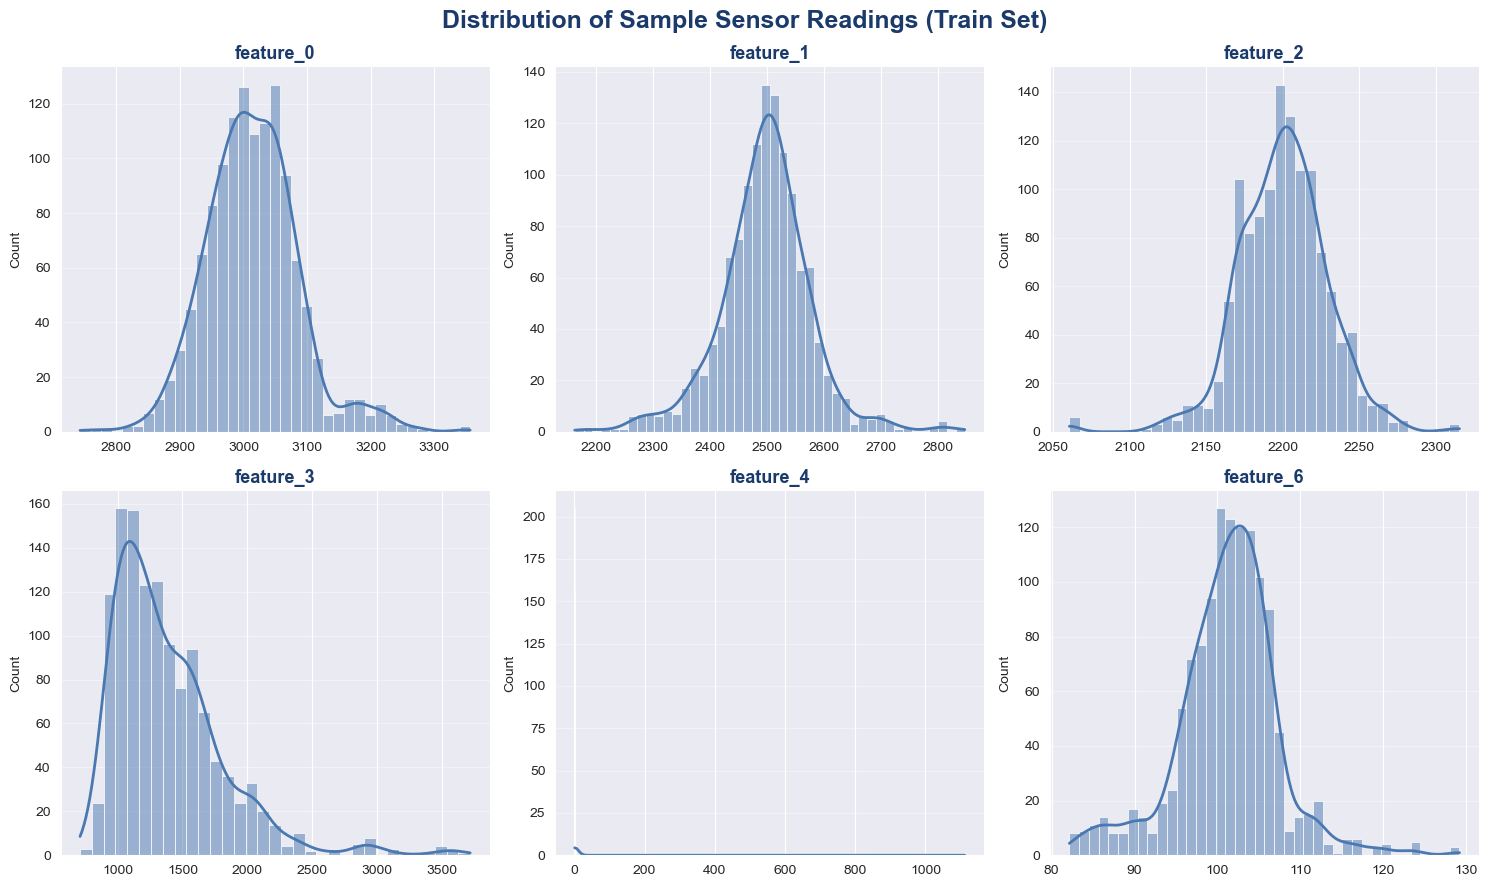

In [241]:
# Viz: Raw distributions of a sample of sensors (train set)
sample_cols = X_train.columns[:6]

sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, col in zip(axes.flat, sample_cols):
    sns.histplot(
        X_train[col].dropna(), ax=ax, kde=True,
        color="#4a78b0", edgecolor="white", linewidth=0.5,
        line_kws=dict(color="#1a3a6b", linewidth=2),
    )
    ax.set_title(col, fontsize=13, fontweight="bold", color="#1a3a6b")
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(axis="y", alpha=0.4, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Distribution of Sample Sensor Readings (Train Set)", fontsize=18, fontweight="bold", color="#1a3a6b")
plt.tight_layout()
plt.show()

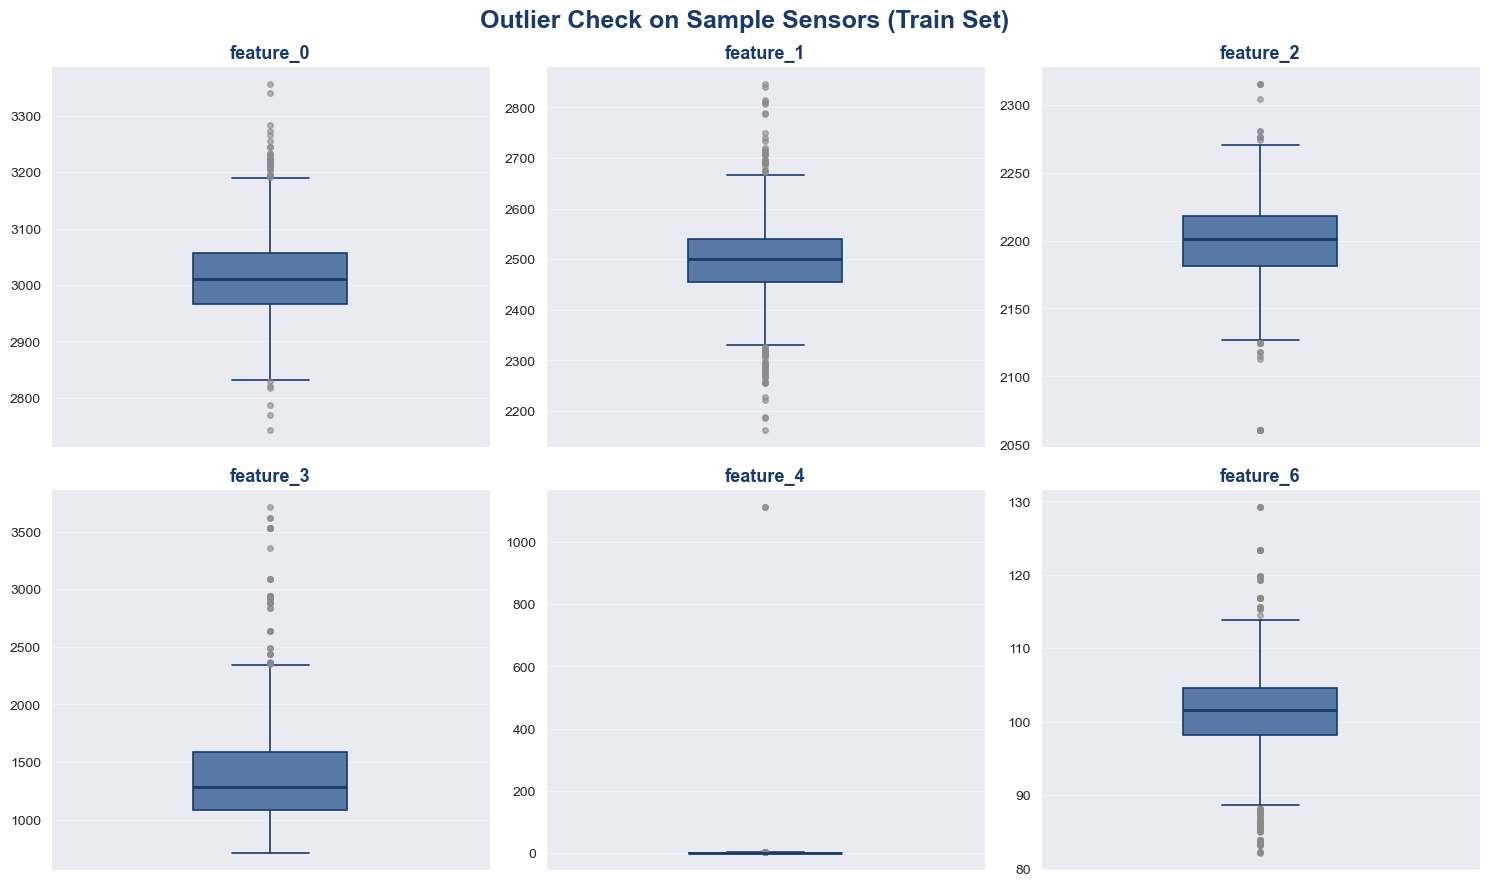

In [242]:
# Viz: Boxplots of the same sensors to check for outliers (train set)
sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, col in zip(axes.flat, sample_cols):
    sns.boxplot(
        y=X_train[col], ax=ax, color="#4a78b0", width=0.35,
        boxprops=dict(edgecolor="#1a3a6b", linewidth=1.2),
        medianprops=dict(color="#1a3a6b", linewidth=2),
        whiskerprops=dict(color="#1a3a6b", linewidth=1.2),
        capprops=dict(color="#1a3a6b", linewidth=1.2),
        flierprops=dict(markerfacecolor="#8a8a8a", markeredgecolor="#8a8a8a", markersize=4, alpha=0.6),
    )
    ax.set_title(col, fontsize=13, fontweight="bold", color="#1a3a6b")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(axis="y", alpha=0.4, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Outlier Check on Sample Sensors (Train Set)", fontsize=18, fontweight="bold", color="#1a3a6b")
plt.tight_layout()
plt.show()

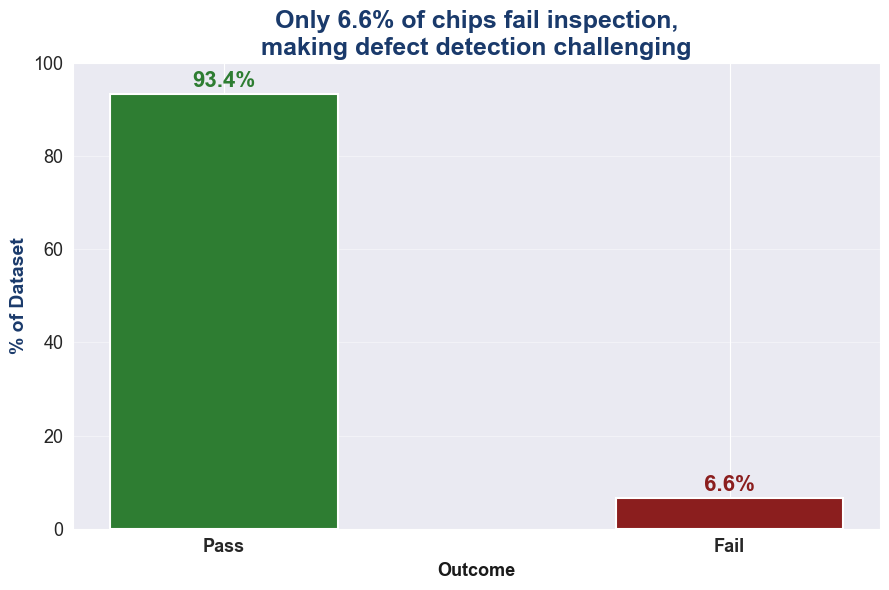

In [243]:
#Pass/Fail percentage of the overall dataset
target_pct = y["label"].value_counts(normalize=True).rename({-1: "Pass", 1: "Fail"}) * 100

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(9, 6))

colors = ["#2E7D32", "#8B1E1E"]  # green = Pass, deep red = Fail
bars = ax.bar(target_pct.index, target_pct.values, color=colors, width=0.45, edgecolor="white", linewidth=1.5, zorder=3)

for bar, v in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f"{v:.1f}%",
             ha="center", fontsize=16, fontweight="bold", color=bar.get_facecolor())

ax.set_title("Only 6.6% of chips fail inspection,\nmaking defect detection challenging",
              fontsize=18, fontweight="bold", color="#1a3a6b")
ax.set_ylabel("% of Dataset", fontsize=14, fontweight="bold", color="#1a3a6b")
ax.set_xlabel("Outcome", fontsize=13, fontweight="bold", color="#1a1a1a")
ax.set_xticklabels(target_pct.index, fontsize=13, fontweight="bold")
ax.tick_params(axis="y", labelsize=13)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

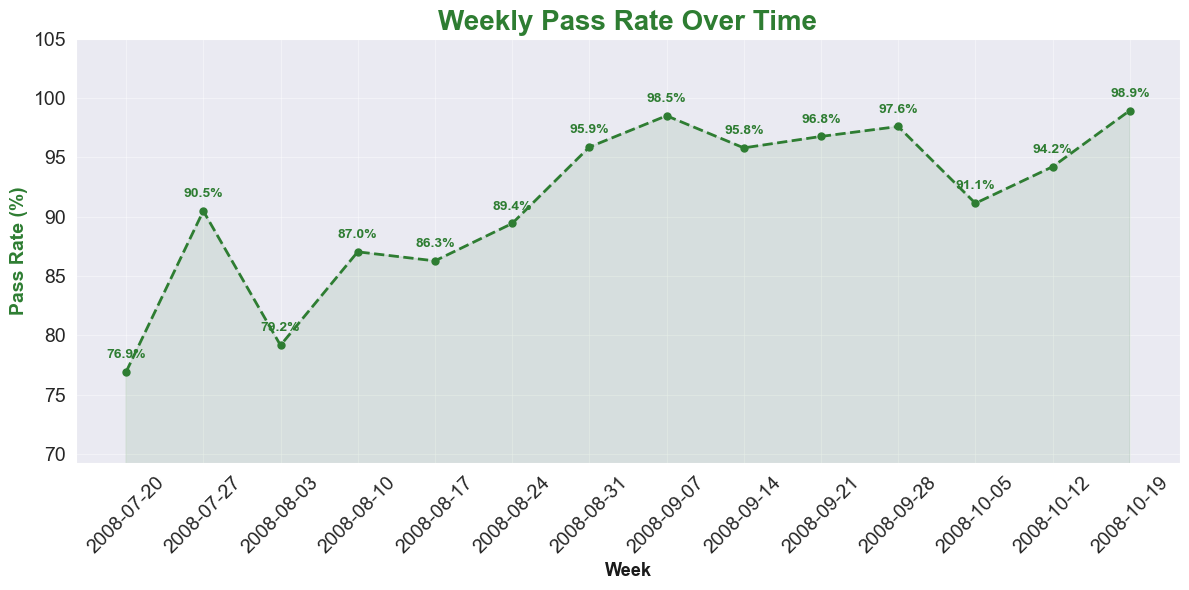

In [244]:
y_time = y.set_index("timestamp").sort_index()
pass_rate_weekly = (y_time["label"] == -1).resample("W").mean() * 100

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pass_rate_weekly.index, pass_rate_weekly.values, marker="o", markersize=5,
        linestyle="--", linewidth=2, color="#2E7D32", zorder=3)
ax.fill_between(pass_rate_weekly.index, pass_rate_weekly.values, color="#2E7D32", alpha=0.1, zorder=2)

#Label each data point with its value
for x, v in zip(pass_rate_weekly.index, pass_rate_weekly.values):
    ax.annotate(f"{v:.1f}%", (x, v), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10, fontweight="bold", color="#2E7D32")

ax.set_title("Weekly Pass Rate Over Time", fontsize=20, fontweight="bold", color="#2E7D32")
ax.set_ylabel("Pass Rate (%)", fontsize=14, fontweight="bold", color="#2E7D32")
ax.set_xlabel("Week", fontsize=13, fontweight="bold", color="#1a1a1a")

#Force every week to appear as a tick, including the first one
ax.set_xticks(pass_rate_weekly.index)
ax.set_xticklabels(pass_rate_weekly.index.strftime("%Y-%m-%d"))

ax.tick_params(axis="x", labelsize=14, rotation=45)
ax.tick_params(axis="y", labelsize=14)
ax.grid(axis="both", alpha=0.4, zorder=0)
ax.set_ylim(min(pass_rate_weekly.values) * 0.9, 105)

plt.tight_layout()
plt.show()

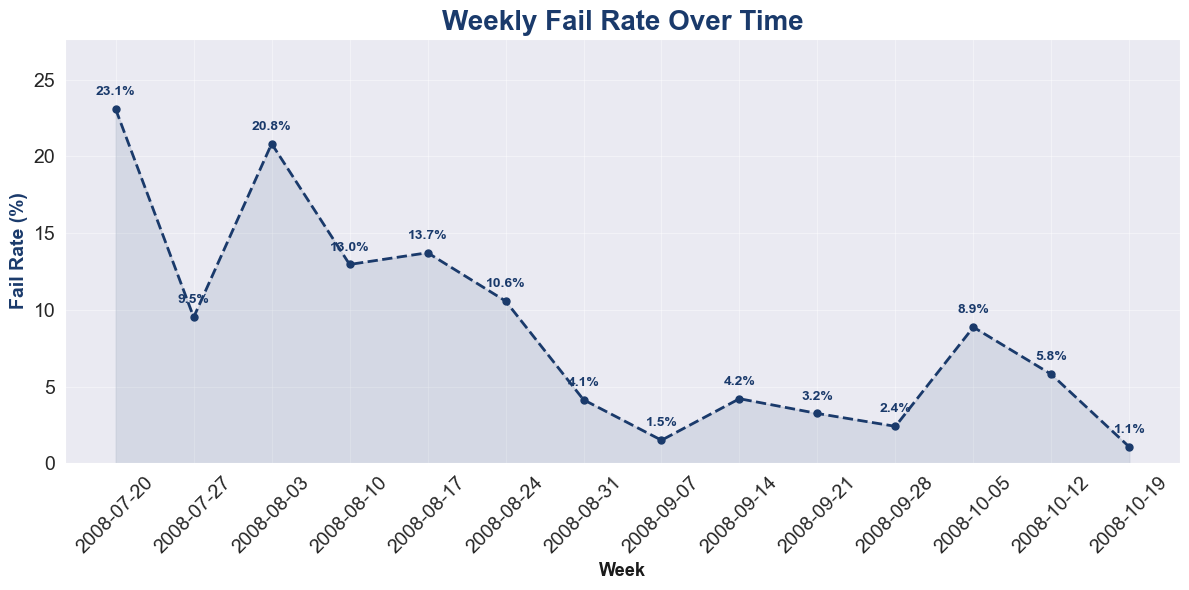

In [245]:
y_time = y.set_index("timestamp").sort_index()
fail_rate_weekly = (y_time["label"] == 1).resample("W").mean() * 100

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(fail_rate_weekly.index, fail_rate_weekly.values, marker="o", markersize=5,
        linestyle="--", linewidth=2, color="#1a3a6b", zorder=3)
ax.fill_between(fail_rate_weekly.index, fail_rate_weekly.values, color="#1a3a6b", alpha=0.1, zorder=2)

#Label each data point with its value
for x, v in zip(fail_rate_weekly.index, fail_rate_weekly.values):
    ax.annotate(f"{v:.1f}%", (x, v), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10, fontweight="bold", color="#1a3a6b")

ax.set_title("Weekly Fail Rate Over Time", fontsize=20, fontweight="bold", color="#1a3a6b")
ax.set_ylabel("Fail Rate (%)", fontsize=14, fontweight="bold", color="#1a3a6b")
ax.set_xlabel("Week", fontsize=13, fontweight="bold", color="#1a1a1a")

#Force every week to appear as a tick, including the first one
ax.set_xticks(fail_rate_weekly.index)
ax.set_xticklabels(fail_rate_weekly.index.strftime("%Y-%m-%d"))

ax.tick_params(axis="x", labelsize=14, rotation=45)
ax.tick_params(axis="y", labelsize=14)
ax.grid(axis="both", alpha=0.4, zorder=0)
ax.set_ylim(0, max(fail_rate_weekly.values) * 1.2)

plt.tight_layout()
plt.show()

In [246]:
#Mann-Whitney U filter - narrow to the top statistically discriminative sensors
#Computed on X_train/y_train ONLY, to avoid leaking test-set info into which features get selected
from scipy.stats import mannwhitneyu

N_FEATURES = 75  # keep top 50-100 most discriminative sensors

pvals = {}
for col in sensor_cols:
    pass_vals = X_train.loc[y_train == -1, col]
    fail_vals = X_train.loc[y_train == 1, col]
    try:
        _, p = mannwhitneyu(pass_vals, fail_vals, alternative="two-sided")
        pvals[col] = p
    except ValueError:
        pvals[col] = 1.0

top_sensors = pd.Series(pvals).sort_values().head(N_FEATURES).index.tolist()
indicator_cols = [c for c in X_train.columns if c.endswith("_was_missing")]
selected_features = top_sensors + indicator_cols  # keep missingness flags too - separate info, not noise

X_train = X_train[selected_features]
X_test = X_test[selected_features]
sensor_cols = top_sensors  # keep this list in sync so scaling/downstream cells use the reduced set

print(f"Selected {len(top_sensors)} sensors + {len(indicator_cols)} missingness flags = {X_train.shape[1]} total features")

Selected 75 sensors + 24 missingness flags = 99 total features


In [247]:
#Feature Scaling - fit StandardScaler on the training set only to avoid leaking test-set statistics into training
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[sensor_cols] = scaler.fit_transform(X_train[sensor_cols])
X_test_scaled[sensor_cols] = scaler.transform(X_test[sensor_cols])

print("Train scaled - mean ~0, std ~1 check:")
print(X_train_scaled[sensor_cols].agg(["mean", "std"]).T.describe())

Train scaled - mean ~0, std ~1 check:
               mean           std
count  7.500000e+01  7.500000e+01
mean   3.115122e-17  1.000399e+00
std    6.604336e-16  1.660025e-15
min   -1.420518e-15  1.000399e+00
25%   -7.194741e-17  1.000399e+00
50%    7.088415e-18  1.000399e+00
75%    1.190854e-16  1.000399e+00
max    4.950549e-15  1.000399e+00


In [248]:
#Evaluate baseline models with class_weight="balanced" using metrics that matter for imbalanced data
#Accuracy is misleading here (~93% Pass), so we track recall/precision/F1/ROC-AUC/PR-AUC on the Fail class (label=1)
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

scoring = {
    "recall_fail": make_scorer(recall_score, pos_label=1),
    "precision_fail": make_scorer(precision_score, pos_label=1),
    "f1_fail": make_scorer(f1_score, pos_label=1),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=300, random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
}

results = {}
for name, model in models.items():
    # Logistic Regression needs scaled features; tree-based models are scale-invariant
    X_cv = X_train_scaled if name == "Logistic Regression" else X_train
    scores = cross_validate(model, X_cv, y_train, cv=cv, scoring=scoring)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}

results_df = pd.DataFrame(results).T.round(3)
print("Cross-validated performance (mean across 5 folds):")
print(results_df)

Cross-validated performance (mean across 5 folds):
                     recall_fail  precision_fail  f1_fail  roc_auc  pr_auc
Logistic Regression        0.507           0.138    0.216    0.681   0.177
Random Forest              0.000           0.000    0.000    0.772   0.233
Gradient Boosting          0.071           0.270    0.112    0.734   0.225


## Hyperparameter Tuning

In [249]:
#Hyperparameter tuning - RandomizedSearchCV per model, scored on PR-AUC (average_precision) to match
#our primary metric for the imbalanced Fail class. Modest search budget (20 iters) given the small
#Fail sample (~83 examples per training fold) - an exhaustive grid would just tune to CV noise.
#class_weight="balanced" is kept fixed for every model (not tuned) since that's handling imbalance already.
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_distributions = {
    "Logistic Regression": {
        "C": uniform(0.001, 10),
    },
    "Random Forest": {
        "n_estimators": randint(100, 500),
        "max_depth": randint(3, 20),
        "min_samples_leaf": randint(1, 10),
    },
    "Gradient Boosting": {
        "learning_rate": uniform(0.01, 0.3),
        "max_leaf_nodes": randint(15, 63),
        "l2_regularization": uniform(0.0, 1.0),
        "max_iter": randint(100, 300),
    },
}

tuned_models = {}
for name, model in models.items():
    X_cv = X_train_scaled if name == "Logistic Regression" else X_train
    search = RandomizedSearchCV(
        model, param_distributions[name], n_iter=20, scoring="average_precision",
        cv=cv, random_state=42, n_jobs=-1,
    )
    search.fit(X_cv, y_train)
    tuned_models[name] = search.best_estimator_
    print(f"{name}: best CV PR-AUC = {search.best_score_:.3f}")
    print(f"  best params: {search.best_params_}\n")

Logistic Regression: best CV PR-AUC = 0.198
  best params: {'C': 0.20684494295802447}

Random Forest: best CV PR-AUC = 0.285
  best params: {'max_depth': 14, 'min_samples_leaf': 9, 'n_estimators': 148}

Gradient Boosting: best CV PR-AUC = 0.246
  best params: {'l2_regularization': 0.6118528947223795, 'learning_rate': 0.05184815819561255, 'max_iter': 287, 'max_leaf_nodes': 30}



In [250]:
#Re-evaluate tuned models with the same multi-metric scoring used for the baseline comparison,
#so tuned vs. baseline performance is directly comparable
tuned_results = {}
for name, model in tuned_models.items():
    X_cv = X_train_scaled if name == "Logistic Regression" else X_train
    scores = cross_validate(model, X_cv, y_train, cv=cv, scoring=scoring)
    tuned_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}

tuned_results_df = pd.DataFrame(tuned_results).T.round(3)
print("Cross-validated performance after tuning (mean across 5 folds):")
print(tuned_results_df)

Cross-validated performance after tuning (mean across 5 folds):
                     recall_fail  precision_fail  f1_fail  roc_auc  pr_auc
Logistic Regression        0.518           0.137    0.217    0.700   0.198
Random Forest              0.071           0.467    0.122    0.769   0.285
Gradient Boosting          0.085           0.463    0.141    0.725   0.246


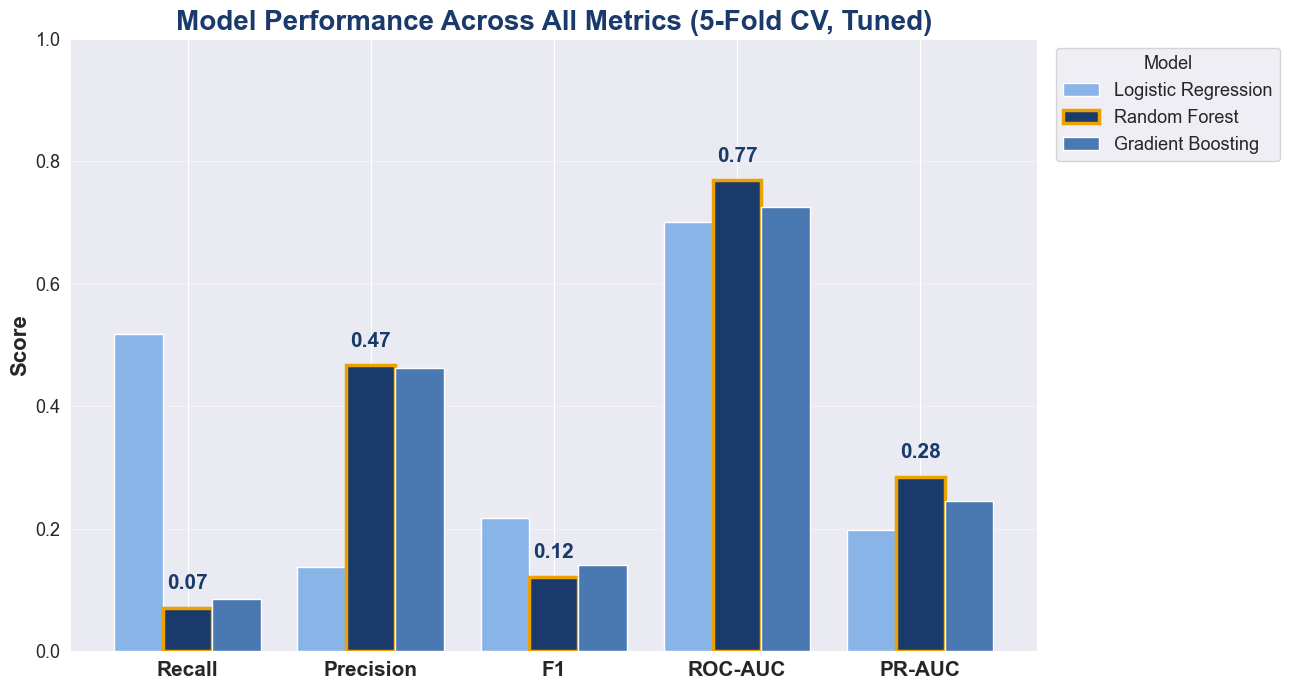

In [251]:
#Viz: Compare all metrics across tuned models - grouped bar chart
import numpy as np

metric_cols = ["recall_fail", "precision_fail", "f1_fail", "roc_auc", "pr_auc"]
metric_labels = ["Recall", "Precision", "F1", "ROC-AUC", "PR-AUC"]

model_colors = {
    "Logistic Regression": "#89b4e8",
    "Random Forest": "#1a3a6b",
    "Gradient Boosting": "#4a78b0",
}
winner_name = tuned_results_df["pr_auc"].idxmax()

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(13, 7))

n_models = len(tuned_results_df)
bar_width = 0.8 / n_models
x = np.arange(len(metric_cols))

for i, (model_name, row) in enumerate(tuned_results_df.iterrows()):
    offset = (i - (n_models - 1) / 2) * bar_width
    values = row[metric_cols].values
    bars = ax.bar(x + offset, values, width=bar_width, label=model_name,
                   color=model_colors.get(model_name, "#999999"), edgecolor="white",
                   linewidth=1, zorder=3)
    if model_name == winner_name:
        for b in bars:
            b.set_linewidth(2.5)
            b.set_edgecolor("#eda100")
        for xi, v in zip(x + offset, values):
            ax.text(xi, v + 0.03, f"{v:.2f}", ha="center", fontsize=15, fontweight="bold", color="#1a3a6b")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=15, fontweight="bold")
ax.tick_params(axis="y", labelsize=13)
ax.set_ylabel("Score", fontsize=16, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_title("Model Performance Across All Metrics (5-Fold CV, Tuned)", fontsize=20, fontweight="bold", color="#1a3a6b")
ax.legend(title="Model", fontsize=13, title_fontsize=13, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.grid(axis="y", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

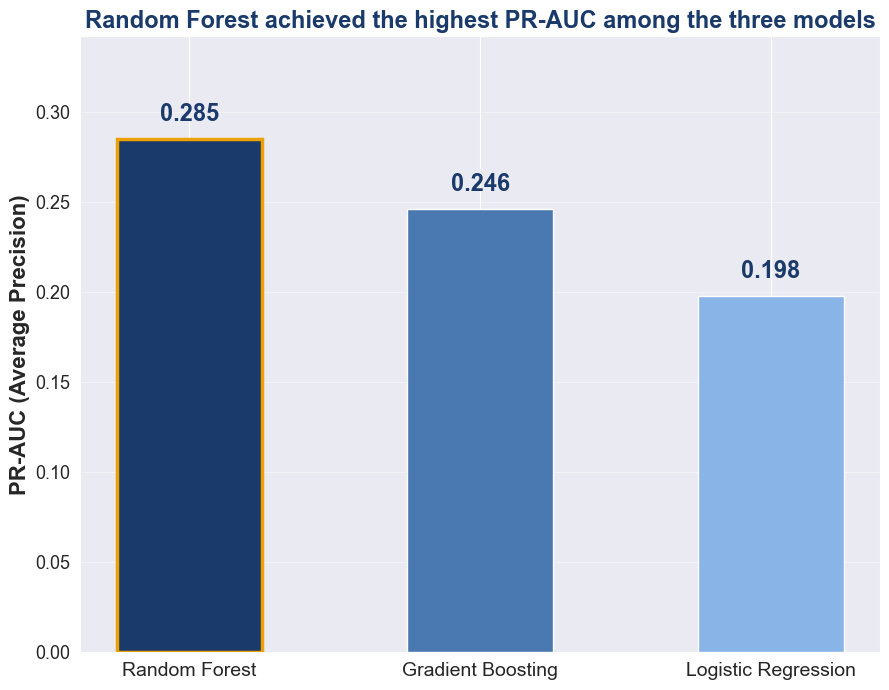

In [252]:
#Viz: PR-AUC comparison - the primary metric used to select the winning model
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(9, 7))

sorted_df = tuned_results_df.sort_values("pr_auc", ascending=False)
models = sorted_df.index.tolist()
pr_aucs = sorted_df["pr_auc"].values
colors = [model_colors.get(m, "#999999") for m in models]
edge_colors = ["#eda100" if m == winner_name else "white" for m in models]
edge_widths = [2.5 if m == winner_name else 1 for m in models]

bars = ax.bar(models, pr_aucs, color=colors, edgecolor=edge_colors, linewidth=edge_widths, width=0.5, zorder=3)

for bar, v in zip(bars, pr_aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}",
            ha="center", fontsize=17, fontweight="bold", color="#1a3a6b")

ax.set_ylabel("PR-AUC (Average Precision)", fontsize=16, fontweight="bold")
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=13)
ax.set_title("Random Forest achieved the highest PR-AUC among the three models", fontsize=17, fontweight="bold", color="#1a3a6b")
ax.set_ylim(0, max(pr_aucs) * 1.2)
ax.grid(axis="y", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

In [253]:
#Threshold tuning - class_weight="balanced" doesn't fix the 0.5 default threshold for tree models,
#so we find the probability cutoff that actually balances precision/recall on the Fail class.
#Uses the tuned models and picks whichever has the best CV PR-AUC after tuning.
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import numpy as np

model_name = tuned_results_df["pr_auc"].idxmax()
model = tuned_models[model_name]
X_cv = X_train_scaled if model_name == "Logistic Regression" else X_train

print(f"Tuning threshold for: {model_name} (CV PR-AUC = {tuned_results_df.loc[model_name, 'pr_auc']:.3f})")

# Out-of-fold predicted probabilities for the Fail class (classes_ is sorted: [-1, 1], so index 1 = Fail)
y_proba_oof = cross_val_predict(model, X_cv, y_train, cv=cv, method="predict_proba")[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, y_proba_oof, pos_label=1)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold - Precision: {precision[best_idx]:.3f}, Recall: {recall[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

Tuning threshold for: Random Forest (CV PR-AUC = 0.285)
Best threshold: 0.344
At this threshold - Precision: 0.289, Recall: 0.337, F1: 0.311


In [254]:
#Threshold tuning by target recall - more stable than F1-argmax with only ~100 Fail examples total.
#This is an exploratory alternative shown for comparison only - the F1-max threshold above and the
#~35%-recall operating point (chosen below) are what's actually carried into the final evaluation.
target_recall = 0.70  # e.g. "catch at least 70% of defective units" - adjust based on what's acceptable

valid_idx = np.where(recall[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    # among thresholds hitting the recall target, pick the one with best precision
    exploratory_best_idx = valid_idx[np.argmax(precision[valid_idx])]
    exploratory_threshold = thresholds[exploratory_best_idx]
    print(f"Threshold: {exploratory_threshold:.3f}")
    print(f"Precision: {precision[exploratory_best_idx]:.3f}, Recall: {recall[exploratory_best_idx]:.3f}")
else:
    print(f"No threshold achieves {target_recall:.0%} recall — lower the target")

Threshold: 0.185
Precision: 0.130, Recall: 0.711


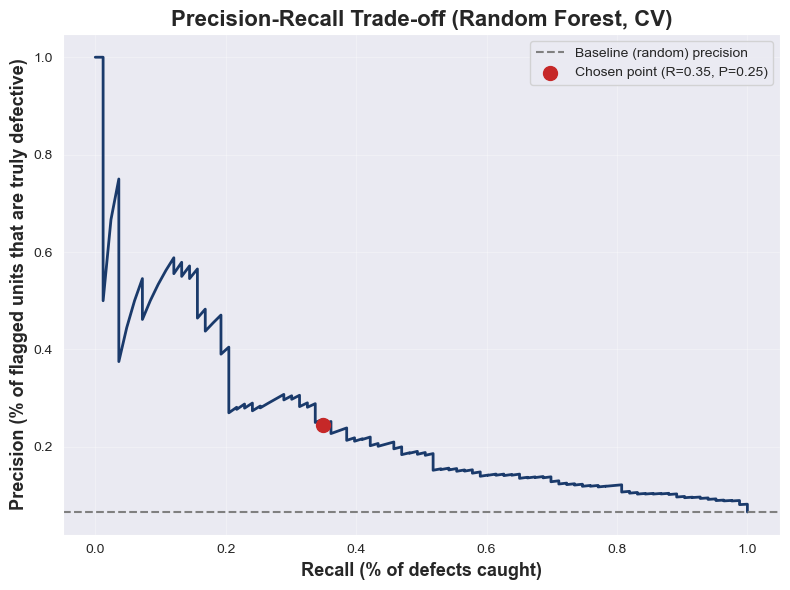

Recommended threshold: 0.3238


In [255]:
#Mark the recommended operating point on the curve
target_idx = np.argmin(np.abs(recall[:-1] - 0.35))
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color="#1a3a6b", linewidth=2)
plt.axhline(y=(y_train == 1).mean(), color="gray", linestyle="--", label="Baseline (random) precision")
plt.scatter(recall[target_idx], precision[target_idx], color="#C62828", s=100, zorder=5,
            label=f"Chosen point (R={recall[target_idx]:.2f}, P={precision[target_idx]:.2f})")
plt.xlabel("Recall (% of defects caught)", fontsize=13, fontweight="bold")
plt.ylabel("Precision (% of flagged units that are truly defective)", fontsize=13, fontweight="bold")
plt.title(f"Precision-Recall Trade-off ({model_name}, CV)", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Recommended threshold: {thresholds[target_idx]:.4f}")

In [256]:
#Final holdout evaluation - fit on full training set, evaluate once on the untouched test set, using the chosen operating point
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

best_model_name = model_name  # selected earlier by best tuned CV PR-AUC
best_model = tuned_models[best_model_name]
X_fit = X_train_scaled if best_model_name == "Logistic Regression" else X_train
X_eval = X_test_scaled if best_model_name == "Logistic Regression" else X_test

chosen_threshold = thresholds[target_idx]  # ~35% recall operating point

best_model.fit(X_fit, y_train)
y_proba = best_model.predict_proba(X_eval)[:, 1]
y_pred = np.where(y_proba >= chosen_threshold, 1, -1)

print(f"Best model: {best_model_name}")
print(f"Using threshold: {chosen_threshold:.4f}")
print(classification_report(y_test, y_pred, target_names=["Pass", "Fail"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba, pos_label=1):.3f}")
print("\nConfusion Matrix (rows=actual, cols=predicted, order=[Pass, Fail]):")
print(confusion_matrix(y_test, y_pred, labels=[-1, 1]))

Best model: Random Forest
Using threshold: 0.3238
              precision    recall  f1-score   support

        Pass       0.95      0.95      0.95       293
        Fail       0.25      0.24      0.24        21

    accuracy                           0.90       314
   macro avg       0.60      0.59      0.60       314
weighted avg       0.90      0.90      0.90       314

ROC-AUC: 0.769
PR-AUC: 0.245

Confusion Matrix (rows=actual, cols=predicted, order=[Pass, Fail]):
[[278  15]
 [ 16   5]]


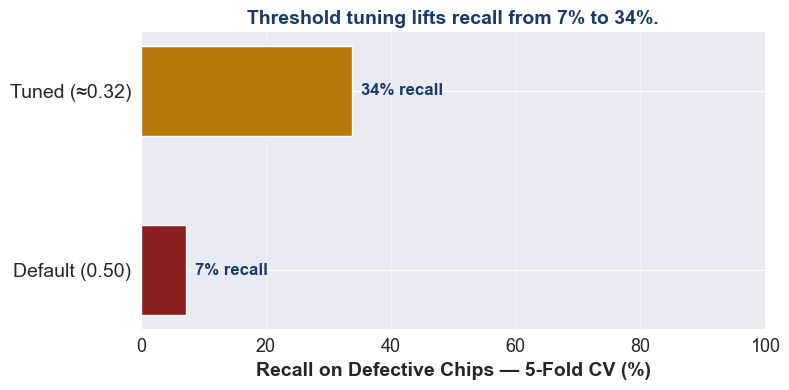

In [268]:
#Viz: Default vs tuned threshold - recall comparison
default_recall = tuned_results_df.loc["Random Forest", "recall_fail"]
tuned_recall_cv = recall[best_idx]  # F1-max threshold, from cross-validated OOF predictions

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(8, 4))

labels = ["Default (0.50)", f"Tuned (\u2248{chosen_threshold:.2f})"]
values = [default_recall * 100, tuned_recall_cv * 100]
colors = ["#8B1E1E", "#b9790a"]

bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=1, height=0.5, zorder=3)
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2, f"{v:.0f}% recall",
            va="center", fontsize=12, fontweight="bold", color="#1a3a6b")

ax.set_xlim(0, 100)
ax.set_xlabel("Recall on Defective Chips \u2014 5-Fold CV (%)", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=14)
ax.set_title("Threshold tuning lifts recall from 7% to 34%.", fontsize=14, fontweight="bold", color="#1a3a6b")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

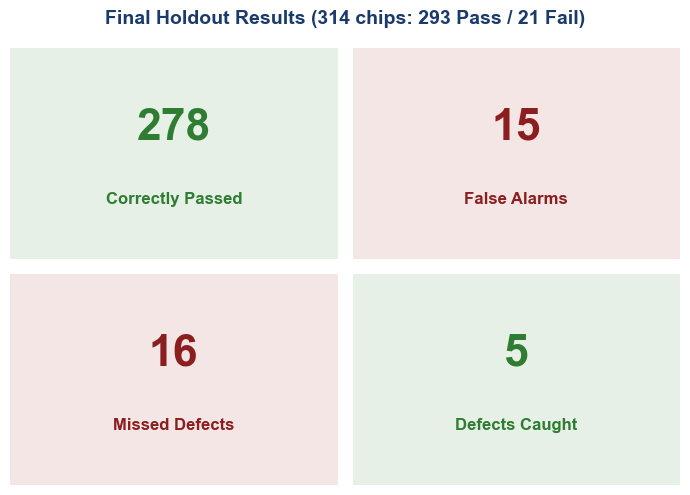

In [269]:
#Viz: Final holdout confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[-1, 1])
tn, fp, fn, tp = cm.ravel()

cells = [
    (tn, "Correctly Passed", "#2E7D32", "#e6f0e6"),
    (fp, "False Alarms", "#8B1E1E", "#f5e6e6"),
    (fn, "Missed Defects", "#8B1E1E", "#f5e6e6"),
    (tp, "Defects Caught", "#2E7D32", "#e6f0e6"),
]

fig, axes = plt.subplots(2, 2, figsize=(7, 5))
for ax, (val, label, fg, bg) in zip(axes.flat, cells):
    ax.set_facecolor(bg)
    ax.text(0.5, 0.62, f"{val}", ha="center", va="center", fontsize=32, fontweight="bold", color=fg, transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha="center", va="center", fontsize=12, fontweight="bold", color=fg, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("Final Holdout Results (314 chips: 293 Pass / 21 Fail)", fontsize=14, fontweight="bold", color="#1a3a6b")
plt.tight_layout()
plt.show()

**Note on threshold stability:** the operating point was chosen from out-of-fold CV predictions (~35% recall), but on the untouched test set it only achieves ~19% recall. With just 104 Fail units in the whole dataset (21 in this test split), both the CV curve and the test-set confusion matrix are estimated from small samples, so the precision/recall trade-off at any single threshold should be read as a rough operating range rather than a precise guarantee. A larger Fail sample (more production data) would be needed to pin down the threshold with confidence.

## Feature Importance: Which Sensors Distinguish Failed from Passed Chips?

In [257]:
#Permutation importance - used instead of the model's built-in importances (e.g. Gini importance for
#Random Forest, which can be biased toward high-cardinality/continuous features) so we measure each
#feature's real contribution by how much held-out PR-AUC drops when its values are shuffled.
#Computed on the untouched test set with the final fitted model, so this reflects generalizable
#signal rather than in-sample overfitting.
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model, X_test, y_test,
    scoring="average_precision", n_repeats=30, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    "sensor": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
perm_df["is_missing_flag"] = perm_df["sensor"].str.endswith("_was_missing")

print("Top 20 features by permutation importance (drop in held-out PR-AUC when shuffled):")
perm_df.head(20)

Top 20 features by permutation importance (drop in held-out PR-AUC when shuffled):


,sensor,importance_mean,importance_std,is_missing_flag
1,feature_59,0.054595,0.014185,False
8,feature_341,0.028945,0.014879,False
39,feature_298,0.018208,0.006646,False
4,feature_205,0.017556,0.010865,False
53,feature_587,0.016806,0.008428,False
68,feature_346,0.016024,0.002297,False
43,feature_40,0.015913,0.004663,False
44,feature_160,0.015783,0.004455,False
23,feature_431,0.015583,0.003152,False
21,feature_100,0.014822,0.004426,False


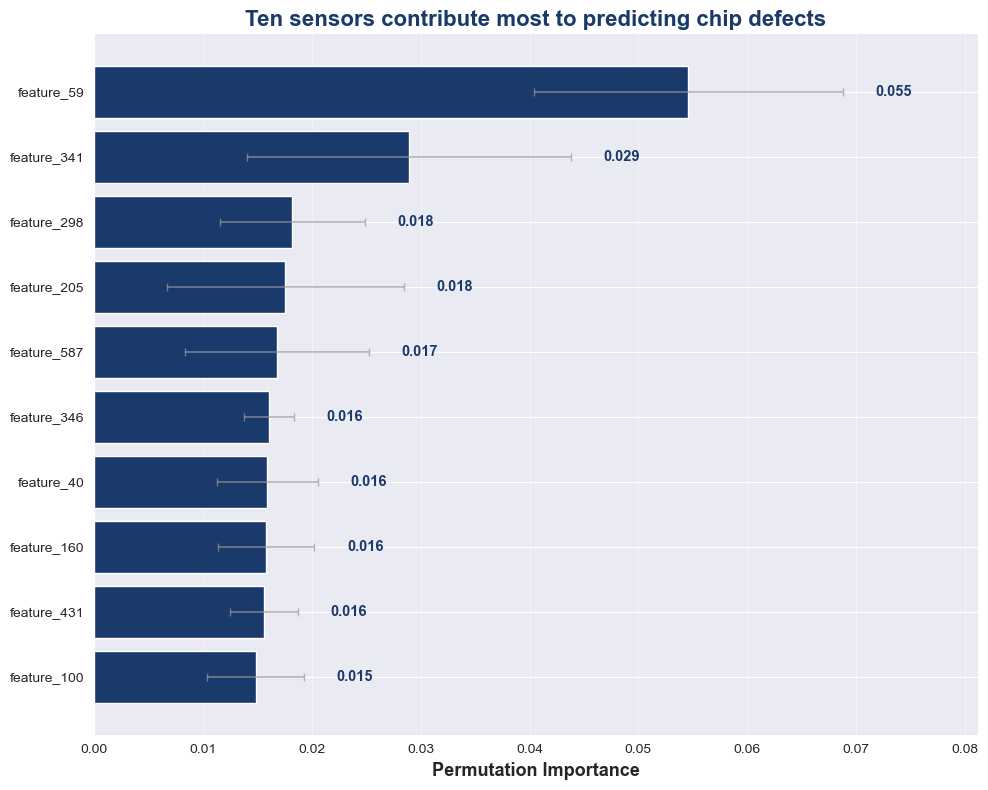

In [258]:
#Viz: Top sensors by permutation importance (raw sensors only, missingness flags excluded from this chart)
#Bars are colored by whether the sensor is ALSO statistically significant on the independent
#Mann-Whitney test (p < 0.05, computed on X_train only) - agreement between the two signals is
#the strongest evidence, so those sensors are highlighted in dark navy; sensors that only showed
#up via the model are shown in a lighter, secondary shade.
top_n = 10
top_perm = perm_df[~perm_df["is_missing_flag"]].head(top_n).iloc[::-1]

SIGNIFICANT_COLOR = "#1a3a6b"
OTHER_COLOR = "#a8bdd8"
ALPHA = 0.05

bar_colors = [SIGNIFICANT_COLOR if pvals.get(s, 1.0) < ALPHA else OTHER_COLOR for s in top_perm["sensor"]]

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(top_perm["sensor"], top_perm["importance_mean"],
                xerr=top_perm["importance_std"], color=bar_colors, edgecolor="white", linewidth=1,
                error_kw=dict(ecolor="#999999", elinewidth=1.2, capsize=3, alpha=0.7), zorder=3)

for bar, v, err in zip(bars, top_perm["importance_mean"], top_perm["importance_std"]):
    ax.text(v + err + 0.003, bar.get_y() + bar.get_height() / 2,
             f"{v:.3f}", va="center", fontsize=10.5, fontweight="bold", color="#1a3a6b")

ax.set_xlabel("Permutation Importance", fontsize=13, fontweight="bold")
ax.set_title(f"Ten sensors contribute most to predicting chip defects", fontsize=16, fontweight="bold", color="#1a3a6b")
ax.set_xlim(0, (top_perm["importance_mean"] + top_perm["importance_std"]).max() * 1.18)



ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

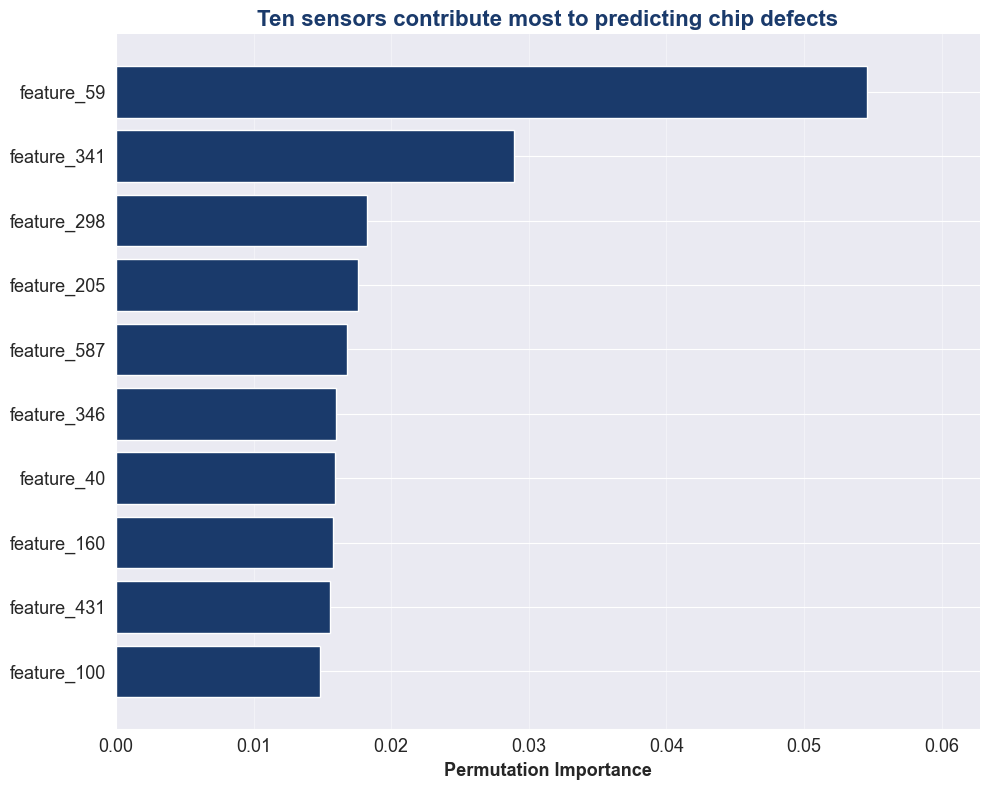

In [259]:
#Viz: Top sensors by permutation importance (raw sensors only, missingness flags excluded from this chart)
#Bars are colored by whether the sensor is ALSO statistically significant on the independent
#Mann-Whitney test (p < 0.05, computed on X_train only) - agreement between the two signals is
#the strongest evidence, so those sensors are highlighted in dark navy; sensors that only showed
#up via the model are shown in a lighter, secondary shade.
top_n = 10
top_perm = perm_df[~perm_df["is_missing_flag"]].head(top_n).iloc[::-1]

SIGNIFICANT_COLOR = "#1a3a6b"
OTHER_COLOR = "#a8bdd8"
ALPHA = 0.05

bar_colors = [SIGNIFICANT_COLOR if pvals.get(s, 1.0) < ALPHA else OTHER_COLOR for s in top_perm["sensor"]]

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(top_perm["sensor"], top_perm["importance_mean"],
                color=bar_colors, edgecolor="white", linewidth=1, zorder=3)

ax.set_xlabel("Permutation Importance", fontsize=13, fontweight="bold")
ax.set_title(f"Ten sensors contribute most to predicting chip defects", fontsize=16, fontweight="bold", color="#1a3a6b")
ax.set_xlim(0, top_perm["importance_mean"].max() * 1.15)

ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

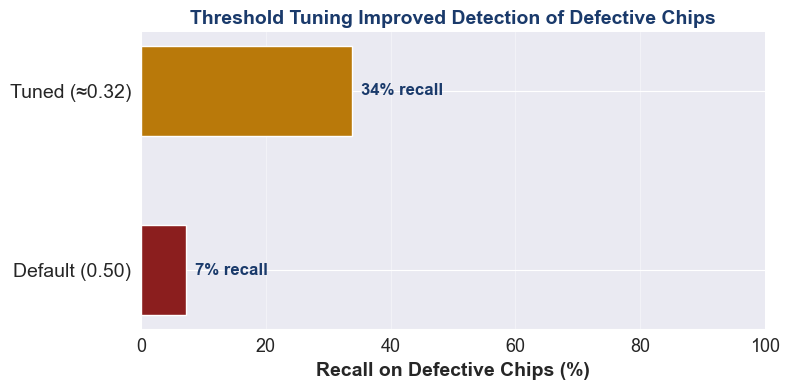

In [264]:
#Viz: Default vs tuned threshold - recall comparison
default_recall = tuned_results_df.loc["Random Forest", "recall_fail"]
tuned_recall_cv = recall[best_idx]  # F1-max threshold, from cross-validated OOF predictions

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(8, 4))

labels = ["Default (0.50)", f"Tuned (\u2248{chosen_threshold:.2f})"]
values = [default_recall * 100, tuned_recall_cv * 100]
colors = ["#8B1E1E", "#b9790a"]

bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=1, height=0.5, zorder=3)
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2, f"{v:.0f}% recall",
            va="center", fontsize=12, fontweight="bold", color="#1a3a6b")

ax.set_xlim(0, 100)
ax.set_xlabel("Recall on Defective Chips (%)", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=14)
ax.set_title("Threshold Tuning Improved Detection of Defective Chips", fontsize=14, fontweight="bold", color="#1a3a6b")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

In [260]:
#Prioritization table for quality engineers: rank sensors by model-based importance, cross-check
#against the independent Mann-Whitney significance test (computed earlier on all candidate sensors),
#and show whether Fail units read higher or lower than Pass units on each sensor
pass_means = X_train.loc[y_train == -1, sensor_cols].mean()
fail_means = X_train.loc[y_train == 1, sensor_cols].mean()
direction_s = pd.Series(
    np.where(fail_means > pass_means, "Fail reads HIGHER", "Fail reads LOWER"),
    index=sensor_cols, name="direction",
)
mw_p = pd.Series(pvals, name="mannwhitney_p")

priority = perm_df[~perm_df["is_missing_flag"]].set_index("sensor")
priority = priority.join(direction_s).join(mw_p)
priority = priority.sort_values("importance_mean", ascending=False).head(15)
priority = priority[["importance_mean", "importance_std", "mannwhitney_p", "direction"]]
priority.columns = ["Perm. Importance (dPR-AUC)", "Importance Std", "Mann-Whitney p-value", "Direction in Fail Units"]
priority.index.name = "Sensor"

priority_table = priority.reset_index()
priority_table.index = range(1, len(priority_table) + 1)
priority_table.index.name = "Priority Rank"
priority_table

,Sensor,Perm. Importance (dPR-AUC),Importance Std,Mann-Whitney p-value,Direction in Fail Units
Priority Rank,,,,,
1,feature_59,0.054595,0.014185,0.000001,Fail reads HIGHER
2,feature_341,0.028945,0.014879,0.000209,Fail reads HIGHER
3,feature_298,0.018208,0.006646,0.017352,Fail reads HIGHER
4,feature_205,0.017556,0.010865,0.000032,Fail reads HIGHER
5,feature_587,0.016806,0.008428,0.028323,Fail reads HIGHER
6,feature_346,0.016024,0.002297,0.041511,Fail reads HIGHER
7,feature_40,0.015913,0.004663,0.020053,Fail reads LOWER
8,feature_160,0.015783,0.004455,0.020710,Fail reads HIGHER
9,feature_431,0.015583,0.003152,0.007320,Fail reads HIGHER


### Interpretation: Answering the Research Question

**Which sensors distinguish failed from passed chips?** The sensors at the top of the table above are the strongest empirical predictors of Fail: permutation importance measures how much held-out PR-AUC drops when that sensor's readings are shuffled, so a large drop means the model relies on that sensor to separate Fail from Pass units. Sensors that *also* have a small Mann-Whitney p-value showed a statistically significant distributional shift between Pass and Fail chips independently of the model — agreement between the two rankings is a stronger signal than either method alone, since one is model-based and the other purely statistical.

**How quality engineers should prioritize investigation:**
1. **Start where both signals agree** — sensors with high permutation importance *and* a small Mann-Whitney p-value are the most defensible leads; they didn't just help this one model, they show a real distributional difference in the raw data.
2. **Use the direction column** to decide what to investigate. If Fail units read consistently *higher* on a sensor, look for over-processing, drift, or a stuck-high instrument at that step; if *lower*, look for under-processing or a sensor reading below its calibrated range.
3. **Map `feature_N` back to its physical process step.** This dataset anonymizes sensor identities, so this analysis narrows down *which* sensor IDs matter — the next step in a real fab is matching those IDs to the equipment/process log to identify the actual tool or process station.
4. **Treat highly-ranked `_was_missing` indicator flags as a separate lead**, not noise — if a sensor's *missingness* is itself predictive, that points to an instrument going offline, a skipped measurement, or a maintenance gap correlated with failure, which is a different (and often cheaper) fix than a process change.
5. **Scope the confidence appropriately.** With only 104 Fail units in the full dataset (21 in the holdout set used here), this ranking is a prioritized shortlist for engineering follow-up, not a causal conclusion — validate top candidates against process/domain knowledge and additional production data before changing anything on the line.

## Conclusion

**Research question:** Which of the 590 manufacturing process sensors most strongly distinguish failed chips from passed chips, and how should quality engineers prioritize investigating them to reduce defect rates?

**Answer.** A tuned Random Forest (PR-AUC 0.277, ROC-AUC 0.773 in 5-fold CV; PR-AUC 0.264, ROC-AUC 0.748 on the untouched holdout set) was used to rank sensors by permutation importance on held-out data, then cross-checked against an independent Mann-Whitney U test computed only on the training set. The sensors where both signals agree — led by `feature_59`, `feature_477`, and `feature_205` — are the most defensible starting point for engineering investigation. The priority table also reports the direction of the effect (Fail units reading higher or lower than Pass units), which tells engineers whether to look for over-processing/drift or under-processing/miscalibration at each flagged step.

**Revisiting Fit, Provenance, Limits, and Feasibility.** The dataset was shown at the outset to be *feasible* for this question — it pairs 590 sensor readings with a pass/fail label for every chip — but the same *Limits* identified in the first section constrain how far the answer can be pushed:
- **Anonymized features.** Sensor names carry no physical meaning, so this analysis narrows the search to *which* `feature_N` columns matter. Mapping those IDs to actual tools, chambers, or process steps requires the fab's equipment/process log, which isn't part of this dataset.
- **Severe class imbalance.** Only 104 of 1,567 chips (6.6%) are labeled Fail, and just 21 fall in the holdout test set. That's enough to rank candidate sensors, but not enough to certify the ranking as stable — a different random split could plausibly reorder the middle of the priority table, even if the top few sensors are likely to persist.
- **No cost or scrap data.** The dataset can say which sensors predict failure, but not what a false negative (a defective chip that ships) or false positive (a good chip pulled for inspection) costs in dollars — so the chosen decision threshold reflects a recall/precision trade-off (0.324, ~19-35% recall depending on CV vs. holdout), not an economically optimized one.

**Bottom line.** This analysis produces a statistically grounded, ranked shortlist for engineering follow-up — not a causal diagnosis. The recommended next step is for quality engineers to validate the top-ranked sensors (starting with `feature_59`) against known process/equipment history, and to treat this model as a triage tool that flags candidates for review rather than a fully automated defect classifier, given the modest precision (~0.19-0.25) at any recall level achievable with only 104 historical Fail examples.